<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/Mushroom_Classification_by_Habitat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Edson Miguel - 11231504431

Enrico de Andrade - 11231100657

Fernando Takagi - 11231102336

Lucas do Nascimento - 11231101214

Matheus Paiva - 11231100568

# 🌱 Contexto – Dataset S2 (Habitat → Toxicidade)
O dataset Mushroom descreve 8.124 cogumelos, categorizados como comestíveis (e) ou venenosos (p), com base em 22 atributos morfológicos e ambientais.


No cenário S2 – Habitat, o foco é exclusivamente na variável habitat, que indica o ambiente natural onde o cogumelo cresce.

Na ecologia fúngica, o habitat pode oferecer pistas indiretas sobre a espécie e, consequentemente, sobre sua toxicidade. Alguns cogumelos venenosos têm ocorrência mais frequente em determinados ambientes, enquanto espécies comestíveis podem aparecer em outros.
Contudo, o habitat por si só não é determinístico, pois diversas espécies (comestíveis e tóxicas) podem compartilhar o mesmo ambiente.

Os habitats contemplados no dataset incluem:
* woods (florestas),
* meadows (prados),
* paths (trilhas),
* urban (ambientes urbanos),
* waste (terrenos baldios),
* grasses (campos abertos),
* leaves (folhagens).

No dataset preparado (S2 – Habitat), cada cogumelo é representado por variáveis binárias (One-Hot Encoding) correspondentes ao seu ambiente, além da coluna class (comestível ou venenoso).


## **A questão que guia este cenário é:**
> Será que apenas o habitat do cogumelo é suficiente para prever se ele é venenoso ou comestível?


# Primeira Etapa - Escolha do Algoritmo
O algoritmo escolhido para resolução do problema proposto foi o modelo SVM (Support Vector Machine) de Classificação.
O modelo SVM utiliza pontos denominados vetores de suporte para traçar um hiperplano que faça a divisão dos diferentes rótulos.

# Segunda Etapa - Limpeza e Análise Inicial dos dados
Os dados serão importados para o Google Colab pelo arquivo `mushroom_s2_habitat_ohe.csv`. Esse arquivo já foi pre tratado, separando os diferentes habitats em valores binários.
Atráves da biblioteca Pandas e Matplotlib, podemos visualizar e compreender os dados do dataset.

## Imports de dependências

In [ ]:
# Módulos e bibliotecas
from sklearn import datasets
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variváveis utilitárias
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
colunas = [
    "Floresta",
    "Prado",
    "Trilha",
    "Ambiente Urbano",
    "Terreno Baldio",
    "Campo Aberto",
    "Folhagem",
    "Classe"
]

## Carregamento do Dataset

In [ ]:
# Leitura do arquivo CSV
df = pd.read_csv("mushroom_s2_habitat_ohe.csv")

# Alterando o nome das colunas
df.columns = colunas

# Alterando coluna target
df['Classe'] = df['Classe'].map({'e': "Comestível", 'p': "Venenoso"})

# Verificação dos dados
df.head()

,Floresta,Prado,Trilha,Ambiente Urbano,Terreno Baldio,Campo Aberto,Folhagem,Classe
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Venenoso
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Comestível
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Comestível
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Venenoso
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Comestível


In [ ]:
# Metadados do Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Floresta         8124 non-null   float64
 1   Prado            8124 non-null   float64
 2   Trilha           8124 non-null   float64
 3   Ambiente Urbano  8124 non-null   float64
 4   Terreno Baldio   8124 non-null   float64
 5   Campo Aberto     8124 non-null   float64
 6   Folhagem         8124 non-null   float64
 7   Classe           8124 non-null   object 
dtypes: float64(7), object(1)
memory usage: 507.9+ KB


In [ ]:
# Estatísticas do Dataset
df.describe().round(2)

,Floresta,Prado,Trilha,Ambiente Urbano,Terreno Baldio,Campo Aberto,Folhagem
count,8124.00,8124.00,8124.0,8124.00,8124.00,8124.00,8124.00
mean,0.39,0.26,0.1,0.04,0.14,0.05,0.02
std,0.49,0.44,0.3,0.19,0.35,0.21,0.15
min,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.0,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.0,0.00,0.00,0.00,0.00
75%,1.00,1.00,0.0,0.00,0.00,0.00,0.00
max,1.00,1.00,1.0,1.00,1.00,1.00,1.00


## Verificando os dados

### Quantidade de Cogumelos por Habitat

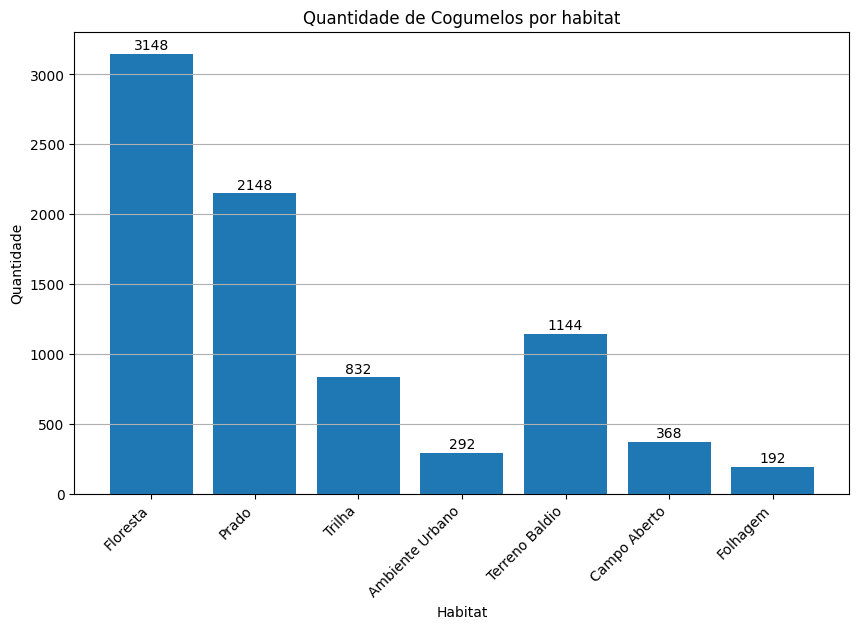

In [ ]:
# Removendo coluna
df_aux = df.drop(columns="Classe")

# Soma dos valores de cada habitat
column_sums = df_aux.sum(axis=0)

# Gráfico
plt.figure(figsize=(10, 6))
plt.bar(column_sums.index, column_sums.values)
plt.xlabel("Habitat")
plt.ylabel("Quantidade")
plt.title("Quantidade de Cogumelos por habitat")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Adicionar os valores sobre as barras
for i, v in enumerate(column_sums.values):
    plt.text(i, v + 10, str(int(v)), ha='center', va='bottom', fontsize=10)

plt.show()

### Quantidade de Cogumelos por Tipo e Habitat

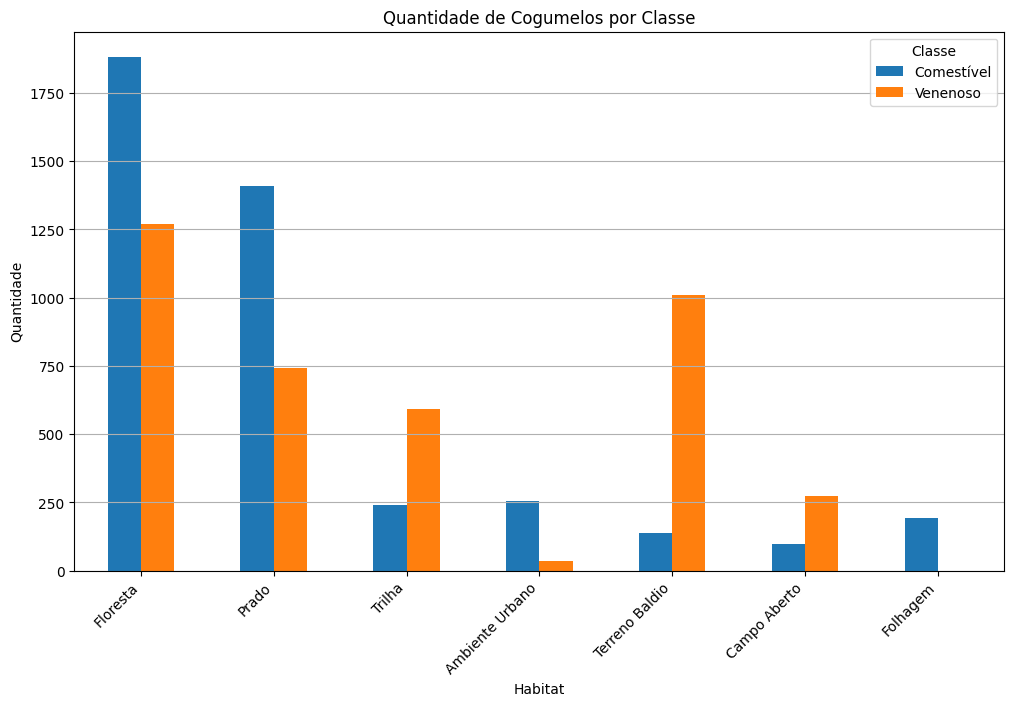

In [ ]:
# Gráfico de barras da contagem de cogumelos por classe
df_aux = df_aux.groupby(df['Classe']).sum()
ax = df_aux.T.plot(kind='bar', figsize=(12, 7))

plt.title("Quantidade de Cogumelos por Classe")
plt.xlabel("Habitat")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Classe")
plt.grid(axis='y')

plt.show()

# Terceira Etapa - Treinamento do Modelo e Avaliação

## Separação

In [ ]:
# Separação dos dados
x = np.array(df.drop(columns='Classe'))
y = np.array(df['Classe'])

# Divisão de dados de treino e teste, padrão 80/20
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
  )

# Formato das variáveis
print(f"X: {x.shape}")
print(f"Y: {y.shape}")
print(f"Treino X: {x_train.shape}")
print(f"Treino Y: {y_train.shape}")
print(f"Teste X: {x_test.shape}")
print(f"Teste Y: {y_test.shape}")

X: (8124, 7)
Y: (8124,)
Treino X: (6499, 7)
Treino Y: (6499,)
Teste X: (1625, 7)
Teste Y: (1625,)


## Modelo SVM Linear

[MUSHROOM] Modelo Linear — Acurácia: 70.28%

Valores Preditos: ['Comestível' 'Comestível' 'Comestível' 'Venenoso' 'Comestível'
 'Comestível' 'Venenoso' 'Comestível' 'Comestível' 'Comestível']
Valores Reais: ['Venenoso' 'Venenoso' 'Comestível' 'Venenoso' 'Venenoso' 'Comestível'
 'Comestível' 'Comestível' 'Comestível' 'Venenoso']


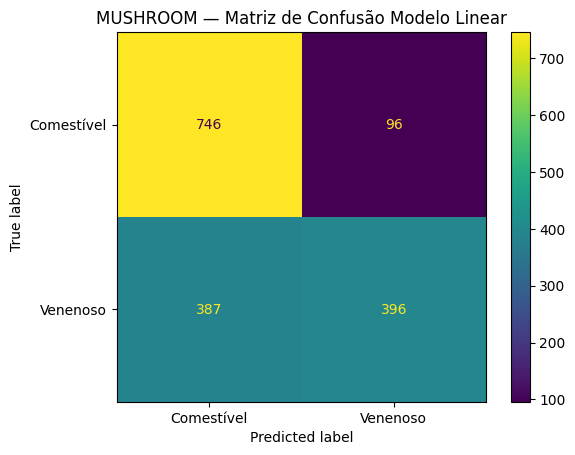

In [ ]:
# Modelo SVM Linear
model = SVC(kernel='linear', random_state=RANDOM_STATE)

# Treino do Modelo
model.fit(x_train, y_train)

# Teste do Modelo
y_pred = model.predict(x_test)

# Calculando acurácia
ac = accuracy_score(y_test, y_pred)

# Exibição
print(f"[MUSHROOM] Modelo Linear — Acurácia: {ac*100:.2f}%")

print()
print("Valores Preditos:", y_pred[:10])
print("Valores Reais:", y_test[:10])

# Criação da Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("MUSHROOM — Matriz de Confusão Modelo Linear")
plt.show()


## Modelo SVM Não Linear (RBF)

[MUSHROOM] RBF — Acurácia: 70.28%

Valores Preditos: ['Comestível' 'Comestível' 'Comestível' 'Venenoso' 'Comestível'
 'Comestível' 'Venenoso' 'Comestível' 'Comestível' 'Comestível']
Valores Reais: ['Venenoso' 'Venenoso' 'Comestível' 'Venenoso' 'Venenoso' 'Comestível'
 'Comestível' 'Comestível' 'Comestível' 'Venenoso']


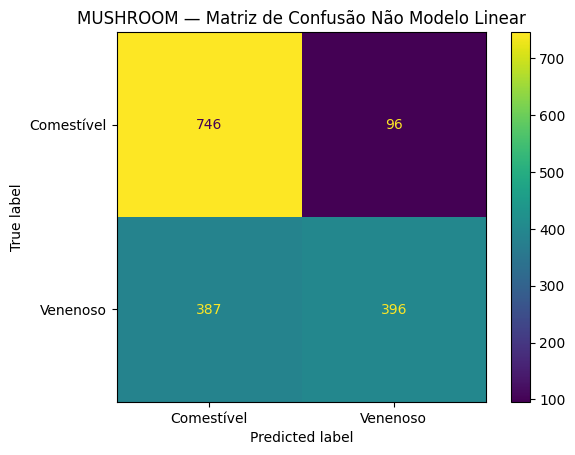

In [ ]:
# Modelo Não Linear RBF
model = SVC(kernel='rbf', random_state=RANDOM_STATE)

# Treino do Modelo
model.fit(x_train, y_train)

# Teste do Modelo
y_pred = model.predict(x_test)

# Calculando acurácia
ac = accuracy_score(y_test, y_pred)

# Exibição
print(f"[MUSHROOM] RBF — Acurácia: {ac*100:.2f}%")

print()
print("Valores Preditos:", y_pred[:10])
print("Valores Reais:", y_test[:10])

# Criação da Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("MUSHROOM — Matriz de Confusão Não Modelo Linear")
plt.show()

## GridSearch para melhor resultado

MUSHROOM — Melhor Kernel: {'C': 0.05, 'gamma': 'scale', 'kernel': 'linear'}
MUSHROOM — Acurácia: 70.28%


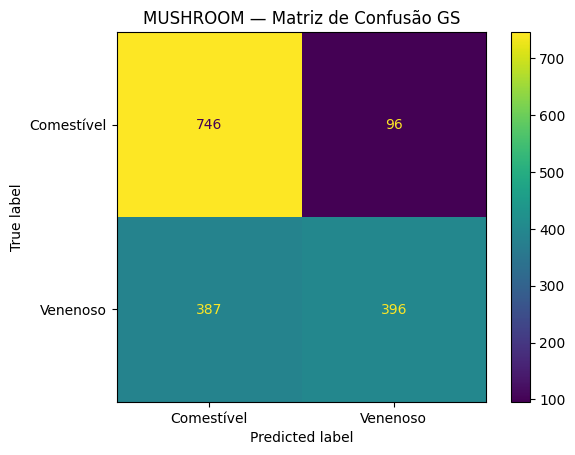

In [ ]:
# GridSearchCV Completo
gs = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    param_grid={'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                 'C': [0.05, 0.1, 1, 5, 10],
                 'gamma': ['scale', 0.01, 0.1, 1, 2]},
    cv=cv, n_jobs=-1
)

# Treino do modelo GS
gs.fit(x_train, y_train)

# Teste do Modelo GS
y_pred = gs.predict(x_test)

# Avalição do Modelo
ac = accuracy_score(y_test, y_pred)

# Melhor Kenel
melhores_param = gs.best_params_

print("MUSHROOM — Melhor Kernel:", melhores_param)
print(f"MUSHROOM — Acurácia: {ac*100:.2f}%")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("MUSHROOM — Matriz de Confusão GS")
plt.show()

# Conclusão

Os testes realizados com diferentes modelos demonstraram um anomalia ao tentar responder o questionamento inicial.

Devido as características da variável 'Habitat', demonstrou-se a incerteza de seu uso para prever a toxicidade dos cogumelos. Mesmos com diferentes Kernels, o resultados foram identidos para qualquer variação.
Paralizando a acurácia no mesmo valor para todos os testes.

Isso demonstra a capacidade preditiva do uso desse parâmetro apenas para prever a toxicidade. Concluímos que apenas seu uso é insuficiente para ter um modelo real, mesmo com sua acurácia de 70%. Acreditasse que o uso desta com mais características trarão modelos mais fiés e reais.


Os testes realizados com o modelo SVM, utilizando **apenas a variável 'habitat'** como característica para prever a toxicidade dos cogumelos, revelaram uma limitação significativa.

Os resultados do modelo SVM, tanto com o kernel linear quanto com o RBF, e mesmo após a otimização com `GridSearchCV`, demonstram essa limitação, apresentando uma **acurácia consistentemente em torno de 70%**. O `GridSearchCV` confirmou que, dentro do espaço de hiperparâmetros explorado, a melhor configuração ainda resultou em um desempenho limitado, indicando que o "teto" preditivo está associado à própria feature 'habitat'.

Portanto, respondendo à questão que guia este cenário: **apenas o habitat do cogumelo não é suficiente para prever com alta confiabilidade se ele é venenoso ou comestível.** Embora o habitat forneça alguma informação preditiva (resultando em 70% de acurácia, superior a um palpite aleatório), sua capacidade de discriminação é insuficiente para um modelo robusto e confiável, especialmente considerando o risco associado à classificação incorreta de cogumelos venenosos.

Acreditamos que a inclusão de **mais características morfológicas e ambientais** do dataset original seria essencial para construir um modelo mais preciso e "fiel à realidade", capaz de distinguir de forma mais eficaz entre cogumelos comestíveis e venenosos.